### Notebook for test and demonstration of Planets objects

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from mad.objs import Planet, PlanetConfig, ProjectileConfig
from mad.configs.planets_cfg import EARTH_SETTINGS
from mad.utils.plotters import plot_2D_planet_with_points
from mad.utils.objs_helpers import random_point_at_planet_surface, point_at_planet_surface_distance

In [3]:
# Planets are built from a PlanetConfig object, which contains all the necessary parameters to create a planet.
EARTH_SETTINGS["position"] = [0, 0] # Making it 2D
earth = Planet(PlanetConfig(**EARTH_SETTINGS))

# It has a convenient __repr__ method to display its main parameters needed when using them in the simulation.
earth

Planet Earth at [0 0 0]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: 9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [4]:
# These convenience functions allow you to create points on the surface of a planet, either randomly or at a specific distance from another point.
# They return a MovableObj with the position set to the surface of the planet (+/- altitude), and the name set to the provided name.
launchsite = random_point_at_planet_surface(earth, name="Launchpad")
target = point_at_planet_surface_distance(earth, launchsite, distance_km=5000, name="Target")

launchsite, target, f"Distance from {launchsite.name} to {target.name}: {earth.surface_distance(launchsite, target)/1000:.2f} km"

(Launchpad at [5949354.29037149 2279243.72275945       0.        ], velocity [0. 0. 0.], active.,
 Target at [2598604.226778   5816960.07315432       0.        ], velocity [0. 0. 0.], active.,
 'Distance from Launchpad to Target: 5000.00 km')

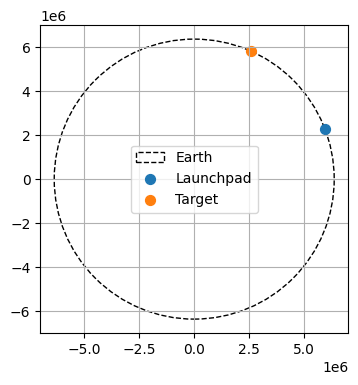

In [5]:
# ANother plotter function that allows you to plot a planet and points on its surface.
fig = plot_2D_planet_with_points(planet=earth, points=[launchsite, target])


Planet objects contain both gravity() and drag() methods used on any object to determine the gravity and drag accelerations. 

As we are in ECEF-like coordinate system, we get 3 components for each force.

Drag needs an object with a defined surface and drag coefficient (even if they are set to 0). This is the case for Projectiles:

In [11]:
# Any object can be created from its configuration dataclass. For example, a rock can be created from a ProjectileConfig object.
rock_cfg = ProjectileConfig(name="Rock", mass=1.0)
# The rock is created at the launchsite position without any velocity.
rock = rock_cfg.create(position=launchsite.position.copy())

In [12]:
# Let's check the gravity at the rock's position, its magnitude, and the gravity at the surface of the planet.
# As the rock is at the surface of the planet, the gravity vector should point towards the center of the planet, and its magnitude should be equal to the gravity at the surface.
earth.gravity(rock), np.linalg.norm(earth.gravity(rock)), earth.gravity_at_surface

(array([-9.16972221, -3.51299162, -0.        ]),
 np.float64(9.819618911711402),
 np.float64(9.819649737724955))

In [13]:
# The rock object was created without a velocity, which set it to [0, 0, 0] by default.
# As a result, drag will be null:
earth.drag(rock)

array([0., 0., 0.])

In [14]:
# Let's update the velocity and calculte drag again. The drag should now be non-zero, and it should point in the opposite direction of the velocity.
rock.velocity = np.array([0, 1000, 0]) # Set the rock's velocity to 1000 m/s in the y-direction.

earth.drag(rock)

array([ -0.        , -90.33226273,  -0.        ])